In [1]:
#1. Import all necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 2. Read the CSV DATA

df = pd.read_csv("prep.csv")   

# One-hot encode categorical columns
df = pd.get_dummies(df, drop_first=True)

# Split Dependant and Independant Variables
X = df.drop("classification_yes", axis=1)
y = df["classification_yes"]


In [3]:
# 3. Load all classifier FUNCTIONS

def select_k_best_with_names(X, y, k):
    selector = SelectKBest(score_func=chi2, k=k)
    X_selected = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support()]
    return X_selected, selected_features

def split_and_scale(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=0
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

In [4]:
## 4. Call the Feature list
results = []

k_range = range(1, X.shape[1] + 1)

for k in k_range:
    X_k, _ = select_k_best_with_names(X, y, k)
    X_train, X_test, y_train, y_test = split_and_scale(X_k, y)

    acc_log = evaluate_model(
        LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test
    )
    acc_rf = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=0),
        X_train, y_train, X_test, y_test
    )

    results.append([k, acc_log, acc_rf])

In [5]:
# 5. Create result Dataframe and print 
results_df = pd.DataFrame(results, columns=["Kvalue", "Logistic", "RandomForest"])
results_df["MeanAccuracy"] = results_df[["Logistic", "RandomForest"]].mean(axis=1)

results_df

,Kvalue,Logistic,RandomForest,MeanAccuracy
0,1,0.64,0.66,0.650
1,2,0.75,0.76,0.755
2,3,0.82,0.88,0.850
3,4,0.85,0.91,0.880
4,5,0.94,0.96,0.950
5,6,0.95,0.98,0.965
6,7,0.97,0.99,0.980
7,8,0.97,0.98,0.975
8,9,0.97,0.99,0.980
9,10,0.99,0.99,0.990


In [6]:
# 6. Print the Best k value
best_k = int(results_df.loc[results_df["MeanAccuracy"].idxmax(), "Kvalue"])
print(" Best k selected automatically:", best_k)

 Best k selected automatically: 23


In [7]:
# 7. List all Selected Features
X_selected, selected_features = select_k_best_with_names(X, y, best_k)
print("Selected Features:")
for f in selected_features:
    print(f)

Selected Features:
age
bp
al
su
bgr
bu
sc
sod
hrmo
pcv
wc
rc
sg_b
sg_c
sg_d
pcc_present
ba_present
htn_yes
dm_yes
cad_yes
appet_yes
pe_yes
ane_yes


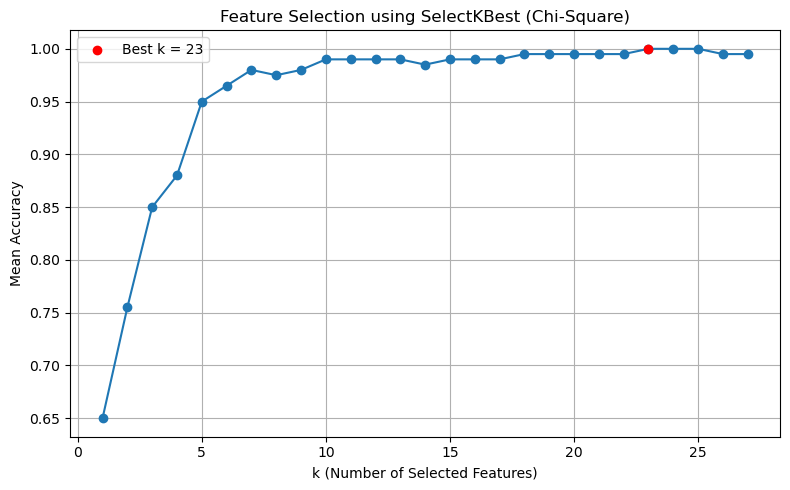

In [8]:
# 8. PLOT ACCURACY vs k graph

plt.figure(figsize=(8,5))
plt.plot(results_df["Kvalue"], results_df["MeanAccuracy"], marker="o")
plt.scatter(
    best_k,
    results_df["MeanAccuracy"].max(),
    color="red",
    label=f"Best k = {best_k}",
    zorder=5
)

plt.xlabel("k (Number of Selected Features)")
plt.ylabel("Mean Accuracy")
plt.title("Feature Selection using SelectKBest (Chi-Square)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()